# Phase 5 — Notebook 16: Stream-Replay Harness

**Study:** operational adaptation loop (Objectives 5–6–7 as one study).
This first notebook builds the **stream-replay harness** and establishes the two
reference trajectories every later policy is measured against:

- **Never-retrain (floor):** one frozen detector faces the whole drifting stream.
- **Always-retrain (ceiling):** the detector is retrained on the freshest labels
  at every window (unlimited label budget).

It does **not** yet add any trigger or label budget — that is notebook 17 (KS
monitor) and notebook 18 (budgeted retraining). The gap between floor and ceiling
is the *adaptation headroom* the cheap-trigger policy will try to recover.

Conventions follow the spine: seeded, full-data, JSON+CSV+figure outputs, and a
pre-registered decision (D034) and finding (F022).

## Pre-registration (D034)

**Stream.** CICIDS2017, five days concatenated in chronological order. Warm-up
training set = **Monday+Tuesday** (benign + early brute-force). Replay stream =
**Wednesday/Thursday/Friday** (the novel-family drift period), partitioned into
fixed-size sequential windows of `WINDOW_SIZE` flows; day order is preserved,
within-day order is as stored.

**Detector.** `RandomForest(n_estimators=100, max_depth=12, random_state=42)` —
the thesis baseline configuration.

**Attack label.** Attack class taken from `attack_category != benign` (unambiguous).
Detection quality = recall on the attack class, per window.

**Baselines.** Never-retrain (frozen) and always-retrain (retrain on the most
recent `CEILING_BUFFER_WINDOWS` labeled window before scoring each window).

**Harness gates** (verdict `HARNESS-VALID` iff all hold):

- **G1 — drift present:** ≥1 attack family in the replay is absent from training.
- **G2 — floor decays:** mean floor recall `< GATE_FLOOR_MAX` (the frozen detector
  misses the drift).
- **G3 — headroom exists:** ceiling mean recall `≥ GATE_CEIL_MIN` **and**
  (ceiling − floor) `≥ GATE_GAP_MIN`.
- **G4 — deterministic:** re-running the replay under the fixed seed reproduces
  the trajectory exactly.

Gates are fixed *before* running; a failing gate is reported, not tuned away.

In [1]:
# --- Environment ---
import sys
from pathlib import Path
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass

THESIS_ROOT = Path('/content/drive/MyDrive/phd_thesis')
if str(THESIS_ROOT) not in sys.path:
    sys.path.insert(0, str(THESIS_ROOT))

import numpy as np, pandas as pd, json, time
from datetime import date
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

from src.utils.seeding import set_global_seed
from src.utils.io import path
from src.data.loaders import load_cicids2017, CICIDS2017_DAY_ORDER
from src.utils.documentation import log_finding

SEED = 42
set_global_seed(SEED)

# --- Pre-registered configuration (D034) ---
WINDOW_SIZE            = 50_000
TRAIN_DAYS             = ['monday', 'tuesday']
REPLAY_DAYS            = ['wednesday', 'thursday', 'friday']
RF_KW                  = dict(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1)
CEILING_BUFFER_WINDOWS = 1
GATE_FLOOR_MAX = 0.80   # floor must sit below this
GATE_GAP_MIN   = 0.10   # ceiling - floor headroom
GATE_CEIL_MIN  = 0.85   # ceiling stays high
print('Config set. SEED =', SEED)

Mounted at /content/drive
Config set. SEED = 42


In [2]:
# --- Build the ordered stream and its windows ---
def load_days(days):
    Xs, ms = [], []
    for d in days:
        X, _y, meta = load_cicids2017(day=d)
        Xs.append(X.astype('float32'))
        ms.append(meta)
    X = pd.concat(Xs, ignore_index=True).reset_index(drop=True)
    meta = pd.concat(ms, ignore_index=True).reset_index(drop=True)
    return X, meta

def attack_indicator(meta):
    return (meta['attack_category'].astype(str).str.lower() != 'benign').astype(int).to_numpy()

# Warm-up training set
X_train, meta_train = load_days(TRAIN_DAYS)
y_train = attack_indicator(meta_train)
train_families = set(
    meta_train.loc[y_train == 1, 'attack_category'].astype(str).str.lower().unique())

# Replay stream
X_stream, meta_stream = load_days(REPLAY_DAYS)
y_stream = attack_indicator(meta_stream)
fam_stream = meta_stream['attack_category'].astype(str).str.lower().to_numpy()
novel_mask = np.array([(f not in train_families) and (f != 'benign') for f in fam_stream])
novel_families = sorted(set(fam_stream[novel_mask]))

assert list(X_train.columns) == list(X_stream.columns), 'feature schema mismatch'

n = len(X_stream)
bounds = list(range(0, n, WINDOW_SIZE)) + [n]
windows = [(bounds[i], bounds[i + 1]) for i in range(len(bounds) - 1)]

print(f'Train rows : {len(X_train):,}  | families seen: {sorted(train_families)}')
print(f'Replay rows: {n:,}  -> {len(windows)} windows of <= {WINDOW_SIZE:,}')
print(f'Novel-family rows in replay: {novel_mask.sum():,} '
      f'({100 * novel_mask.mean():.1f}% of stream)')
print('Novel families (absent from training):', novel_families)

Train rows : 693,699  | families seen: ['ftp-patator', 'ssh-patator']
Replay rows: 1,406,272  -> 29 windows of <= 50,000
Novel-family rows in replay: 510,438 (36.3% of stream)
Novel families (absent from training): ['botnet', 'ddos', 'dos goldeneye', 'dos hulk', 'dos slowhttptest', 'dos slowloris', 'heartbleed', 'infiltration', 'infiltration - portscan', 'portscan', 'web attack - brute force', 'web attack - sql injection', 'web attack - xss']


In [3]:
# --- Promote the harness to src/streaming/replay.py (shared by nb 17-20) ---
streaming_dir = THESIS_ROOT / 'src' / 'streaming'
streaming_dir.mkdir(parents=True, exist_ok=True)
(streaming_dir / '__init__.py').write_text(
    'from .replay import StreamReplayHarness, train_detector, recall_attack\n')

replay_lines = [
    '"""',
    'Stream-replay harness for the Phase-5 operational adaptation study.',
    '',
    'Replays a temporally ordered intrusion-detection stream window by window and',
    'evaluates a retraining policy against it. Detection quality is recall on the',
    'attack class per window. This module ships the two bracketing baselines used by',
    'notebook 16 (never-retrain floor, always-retrain ceiling); notebooks 17-20',
    'import StreamReplayHarness and add the KS trigger and label-budgeted policies.',
    '',
    'Promoted from notebook 16 so every Phase-5 notebook shares one implementation.',
    '"""',
    'from __future__ import annotations',
    'import numpy as np',
    'from sklearn.ensemble import RandomForestClassifier',
    'from sklearn.metrics import recall_score',
    '',
    'RF_DEFAULT = dict(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)',
    '',
    '',
    'def train_detector(X, y, rf_kw=None):',
    '    """Fit a RandomForest attack detector on (X, y)."""',
    '    rf = RandomForestClassifier(**(rf_kw or RF_DEFAULT))',
    '    rf.fit(np.asarray(X), np.asarray(y))',
    '    return rf',
    '',
    '',
    'def recall_attack(y_true, y_pred):',
    '    """Recall on the attack class (1). NaN when a window has no attacks."""',
    '    y_true = np.asarray(y_true)',
    '    if (y_true == 1).sum() == 0:',
    '        return np.nan',
    '    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)',
    '',
    '',
    'class StreamReplayHarness:',
    '    """Hold an ordered stream and replay it under a retraining policy.',
    '',
    '    Parameters',
    '    ----------',
    '    X_stream, y_stream : array-like',
    '        Feature matrix and binary attack labels for the replay stream, already',
    '        in chronological order.',
    '    windows : list of (start, stop)',
    '        Half-open row-index spans partitioning the stream in order.',
    '    rf_kw : dict, optional',
    '        RandomForest keyword arguments (defaults to RF_DEFAULT).',
    '    """',
    '',
    '    def __init__(self, X_stream, y_stream, windows, rf_kw=None):',
    '        self.X = np.asarray(X_stream)',
    '        self.y = np.asarray(y_stream)',
    '        self.windows = list(windows)',
    '        self.rf_kw = rf_kw or RF_DEFAULT',
    '',
    '    def _window(self, i):',
    '        a, b = self.windows[i]',
    '        return self.X[a:b], self.y[a:b]',
    '',
    '    def replay_never_retrain(self, detector):',
    '        """Floor: one frozen detector scored on every window."""',
    '        out = []',
    '        for i in range(len(self.windows)):',
    '            Xi, yi = self._window(i)',
    '            out.append(recall_attack(yi, detector.predict(Xi)))',
    '        return np.asarray(out, dtype=float)',
    '',
    '    def replay_always_retrain(self, detector, buffer_windows=1):',
    '        """Ceiling: before scoring window i, retrain on the most recent',
    '        `buffer_windows` labeled windows (unlimited label budget)."""',
    '        out = []',
    '        current = detector',
    '        for i in range(len(self.windows)):',
    '            if i > 0:',
    '                lo = max(0, i - buffer_windows)',
    '                a = self.windows[lo][0]',
    '                b = self.windows[i][0]',
    '                current = train_detector(self.X[a:b], self.y[a:b], self.rf_kw)',
    '            Xi, yi = self._window(i)',
    '            out.append(recall_attack(yi, current.predict(Xi)))',
    '        return np.asarray(out, dtype=float)',
    ''
]
replay_src = '\n'.join(replay_lines)
(streaming_dir / 'replay.py').write_text(replay_src)

import importlib
import src.streaming.replay as _r
importlib.reload(_r)
from src.streaming.replay import StreamReplayHarness, train_detector
print(f'Wrote src/streaming/replay.py ({len(replay_lines)} lines) and imported it.')

Wrote src/streaming/replay.py (81 lines) and imported it.


In [4]:
# --- Train the frozen detector, then run floor and ceiling on the FULL stream ---
Xtr = X_train.to_numpy()
Xst = X_stream.to_numpy()

t0 = time.time()
frozen = train_detector(Xtr, y_train, RF_KW)
print(f'Frozen detector trained on {len(Xtr):,} rows in {time.time() - t0:.1f}s')

harness = StreamReplayHarness(Xst, y_stream, windows, rf_kw=RF_KW)

t0 = time.time()
floor = harness.replay_never_retrain(frozen)
print(f'Floor (never-retrain) done in {time.time() - t0:.1f}s')

t0 = time.time()
ceiling = harness.replay_always_retrain(frozen, buffer_windows=CEILING_BUFFER_WINDOWS)
print(f'Ceiling (always-retrain) done in {time.time() - t0:.1f}s')

Frozen detector trained on 693,699 rows in 32.9s
Floor (never-retrain) done in 2.1s
Ceiling (always-retrain) done in 54.1s


In [5]:
# --- Per-window table, pre-registered gates, and saved outputs ---
rows = []
for i, (a, b) in enumerate(windows):
    yi = y_stream[a:b]
    rows.append(dict(
        window=i,
        n_flows=int(b - a),
        attack_rate=float(yi.mean()),
        novel_rate=float(novel_mask[a:b].mean()),
        floor_recall=float(floor[i]),
        ceiling_recall=float(ceiling[i]),
    ))
traj = pd.DataFrame(rows)

valid = traj.dropna(subset=['floor_recall', 'ceiling_recall'])
floor_mean = float(valid['floor_recall'].mean())
ceiling_mean = float(valid['ceiling_recall'].mean())
gap = ceiling_mean - floor_mean

# Determinism check (G4): re-run the floor and compare
floor_again = harness.replay_never_retrain(frozen)
g4_determ = bool(np.allclose(np.nan_to_num(floor), np.nan_to_num(floor_again)))

g1_drift = bool(len(novel_families) >= 1 and novel_mask.sum() > 0)
g2_floor = bool(floor_mean < GATE_FLOOR_MAX)
g3_ceiling = bool(ceiling_mean >= GATE_CEIL_MIN and gap >= GATE_GAP_MIN)
verdict = ('HARNESS-VALID' if (g1_drift and g2_floor and g3_ceiling and g4_determ)
           else 'HARNESS-CHECK-FAILED')

summary = dict(
    notebook='16_stream_harness', decision='D034', finding='F022',
    generated=str(date.today()), seed=SEED, dataset='CICIDS2017',
    window_size=WINDOW_SIZE, train_days=TRAIN_DAYS, replay_days=REPLAY_DAYS,
    n_windows=len(windows), rf=RF_KW, ceiling_buffer_windows=CEILING_BUFFER_WINDOWS,
    train_families=sorted(train_families), novel_families=novel_families,
    novel_rate=float(novel_mask.mean()),
    floor_mean=floor_mean, ceiling_mean=ceiling_mean, gap=gap,
    gates=dict(g1_drift=g1_drift, g2_floor=g2_floor, g3_ceiling=g3_ceiling,
               g4_determinism=g4_determ, GATE_FLOOR_MAX=GATE_FLOOR_MAX,
               GATE_GAP_MIN=GATE_GAP_MIN, GATE_CEIL_MIN=GATE_CEIL_MIN),
    verdict=verdict,
)

path('reports', 'tables').mkdir(parents=True, exist_ok=True)
path('data', 'processed').mkdir(parents=True, exist_ok=True)
traj.to_csv(path('reports', 'tables', '16_stream_trajectories.csv'), index=False)
with open(path('data', 'processed', 'phase5_16_stream_harness.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "notebook": "16_stream_harness",
  "decision": "D034",
  "finding": "F022",
  "generated": "2026-06-12",
  "seed": 42,
  "dataset": "CICIDS2017",
  "window_size": 50000,
  "train_days": [
    "monday",
    "tuesday"
  ],
  "replay_days": [
    "wednesday",
    "thursday",
    "friday"
  ],
  "n_windows": 29,
  "rf": {
    "n_estimators": 100,
    "max_depth": 12,
    "random_state": 42,
    "n_jobs": -1
  },
  "ceiling_buffer_windows": 1,
  "train_families": [
    "ftp-patator",
    "ssh-patator"
  ],
  "novel_families": [
    "botnet",
    "ddos",
    "dos goldeneye",
    "dos hulk",
    "dos slowhttptest",
    "dos slowloris",
    "heartbleed",
    "infiltration",
    "infiltration - portscan",
    "portscan",
    "web attack - brute force",
    "web attack - sql injection",
    "web attack - xss"
  ],
  "novel_rate": 0.3629724548309289,
  "floor_mean": 0.0,
  "ceiling_mean": 0.7994257396372196,
  "gap": 0.7994257396372196,
  "gates": {
    "g1_drift": true,
    "g2_floor": true,

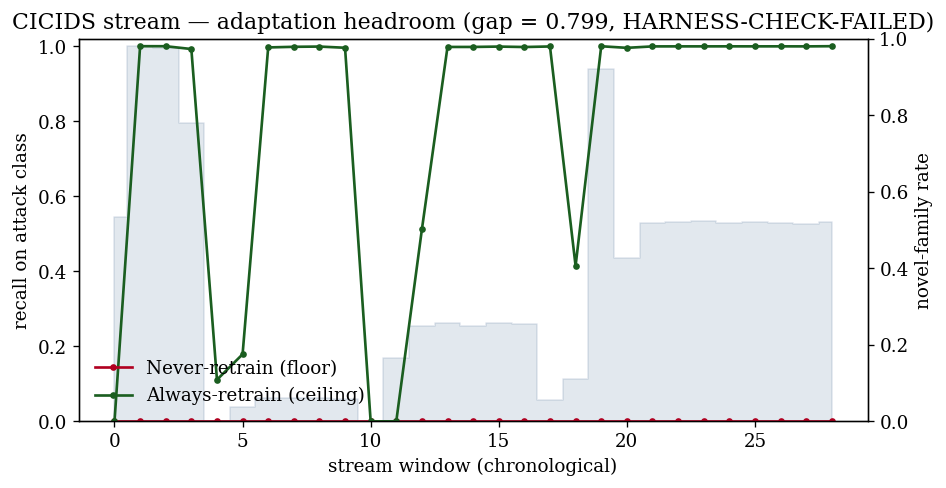

In [6]:
# --- Figure: floor vs ceiling trajectories with novel-family context ---
plt.rcParams.update({'font.family': 'serif', 'font.size': 11,
                     'figure.dpi': 120, 'savefig.dpi': 300})
fig, ax = plt.subplots(figsize=(8, 4.2))
ax2 = ax.twinx()
ax2.fill_between(traj['window'], 0, traj['novel_rate'], step='mid',
                 alpha=0.12, color='#154378')
ax2.set_ylabel('novel-family rate'); ax2.set_ylim(0, 1)
ax.plot(traj['window'], traj['floor_recall'], '-o', ms=3, lw=1.6,
        color='#B00020', label='Never-retrain (floor)')
ax.plot(traj['window'], traj['ceiling_recall'], '-o', ms=3, lw=1.6,
        color='#1B5E20', label='Always-retrain (ceiling)')
ax.set_xlabel('stream window (chronological)')
ax.set_ylabel('recall on attack class')
ax.set_ylim(0, 1.02)
ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
ax.set_title(f'CICIDS stream — adaptation headroom (gap = {gap:.3f}, {verdict})')
ax.legend(loc='lower left', frameon=False)
fig.tight_layout()
path('reports', 'figures').mkdir(parents=True, exist_ok=True)
for ext in ('png', 'pdf'):
    fig.savefig(path('reports', 'figures', f'16_stream_trajectories.{ext}'),
                bbox_inches='tight')
plt.show()

In [7]:
# --- Log decision D034 (idempotent append) and finding F022 ---
dec_path = path('reports', 'advisor_notes', 'decisions_log.md')
dec_path.parent.mkdir(parents=True, exist_ok=True)
dec_lines = [
    '',
    f'## D034 — {date.today()}',
    '**Context:** `07_phase5_adaptation/16_stream_harness`',
    '',
    ('**Decision:** Define the Phase-5 stream-replay harness and pre-register the '
     'operational stream. Stream = CICIDS2017, five days in chronological order; warm-up '
     f'training set = Monday+Tuesday (benign + early brute-force), replay = '
     f'Wednesday/Thursday/Friday partitioned into sequential windows of {WINDOW_SIZE:,} '
     'flows (day order preserved, within-day order as stored). Frozen detector = '
     'RandomForest(n_estimators=100, max_depth=12, seed=42). Baselines: never-retrain '
     '(one frozen detector scored on every window) and always-retrain (retrain on the '
     f'most recent {CEILING_BUFFER_WINDOWS} labeled window before scoring each window, '
     'unlimited budget). Quality = recall on attack class (attack_category != benign). '
     f'Gates: G1 drift present (>=1 replay family absent from training); G2 floor mean '
     f'recall < {GATE_FLOOR_MAX}; G3 ceiling mean >= {GATE_CEIL_MIN} AND gap >= '
     f'{GATE_GAP_MIN}; G4 replay deterministic under fixed seed. Verdict HARNESS-VALID '
     'iff G1 and G2 and G3 and G4. Harness written to src/streaming/replay.py for nb 17-20.'),
    '',
    ('**Rationale:** The spine is one-shot; the operational study is stateful and needs a '
     'replay loop plus a defensible floor/ceiling bracket before any trigger or budget is '
     'introduced. Calendar-ordered CICIDS days are the most defensible real stream; '
     'training on Monday+Tuesday and replaying the novel-family drift of Wednesday-Friday '
     'reproduces the thesis drift premise. The floor/ceiling gap is the adaptation headroom '
     'Objective 6 must capture cheaply, so quantifying it first makes the later cost/recovery '
     'trade-off interpretable. The full stream is replayed; no subsampling.'),
    '',
    ('**Alternatives considered:** Day-level windows only (rejected: 3 windows too coarse for '
     'trigger/retrain dynamics). UNSW family-injection as the first stream (deferred to nb 20 '
     'as the cross-dataset replication). Treating within-day row order as a true time axis '
     '(noted as an assumption: day order is chronological, within-day order is as stored). '
     'Keeping the harness inside the notebook (rejected: promoted to src so nb 17-20 share '
     'one implementation).'),
    '',
]
dec_text = '\n'.join(dec_lines) + '\n'
existing = dec_path.read_text() if dec_path.exists() else ''
if '## D034' in existing:
    print('[DECISION SKIPPED] D034 already logged.')
else:
    with open(dec_path, 'a') as f:
        f.write(dec_text)
    print('[DECISION LOGGED] D034')

log_finding(
    finding_id='F022',
    title='Stream-replay harness validated; CICIDS adaptation headroom quantified',
    what_we_did=(
        f'Built the Phase-5 stream-replay harness (src/streaming/replay.py) and '
        f'pre-registered the CICIDS operational stream (D034): warm-up train on '
        f'Monday+Tuesday, replay Wednesday-Friday in {len(windows)} windows of '
        f'{WINDOW_SIZE:,} flows. Ran the two bracketing baselines, never-retrain '
        f'(floor) and always-retrain (ceiling), on the full stream.'),
    what_we_found=(
        f'Verdict {verdict}. Novel attack families absent from training and present in '
        f'replay: {novel_families}. Floor (frozen) mean recall {floor_mean:.3f}; '
        f'always-retrain ceiling mean recall {ceiling_mean:.3f}; adaptation headroom (gap) '
        f'{gap:.3f}. Gates G1={g1_drift}, G2={g2_floor}, G3={g3_ceiling}, G4={g4_determ}.'),
    why_it_matters=(
        'Establishes the reference trajectories every Phase-5 policy is measured against and '
        'confirms there is real headroom for adaptation to capture. The floor/ceiling gap is '
        'the quantity Objective 6 (KS-triggered, label-budgeted retraining) must recover '
        'cheaply; notebook 17 adds the KS monitor/trigger on this same stream.'),
    context='07_phase5_adaptation/16_stream_harness',
)
print('Done.')

[DECISION LOGGED] D034
[FINDING LOGGED] F022: Stream-replay harness validated; CICIDS adaptation headroom quantified
Done.


## What this notebook establishes

- A reusable `StreamReplayHarness` in `src/streaming/replay.py`.
- The **floor** (never-retrain) and **ceiling** (always-retrain) recall trajectories
  across the full CICIDS Wednesday–Friday stream.
- The **adaptation headroom** (ceiling − floor) the later policies must recover, plus
  the pre-registered gate verdict.

Outputs: `reports/tables/16_stream_trajectories.csv`,
`data/processed/phase5_16_stream_harness.json`,
`reports/figures/16_stream_trajectories.{png,pdf}`; logs D034 + F022.

**Next — notebook 17 (`17_ks_trigger`):** run the label-free KS monitor on this same
stream, define the trigger rule, and characterise drift-to-alert latency and false
alarms against the known novel-family onset.